todos: 

(1) an make some transect plots to see how the plume moves offshore and in the vertical 

(2) quantify the amount of tracer that remains in the surface ocean over time. So adding up the amount of tracer in say the top 100 meters or so and plotting a time series of each simulation
      - when doing the latter, have to do it carefully. The model sees the tracers as a concentration. So to get mass you have multiply by the volume. and you have to do that at each grid cell. And you can’t just assume all the grid cells are the same size, a 1 degree x 1 degree box occupies less and less space as you move away from the equator

In [13]:
using CairoMakie
using Oceananigans
using Oceananigans.Units

In [14]:

# array dimensions are long x lat x depth 
# retrieve fieldtimeseries from original simulation 
dye_on = FieldTimeSeries(
    "amazon_rivers_on_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

dye_off = FieldTimeSeries(
    "amazon_rivers_off_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

170×170×20×61 FieldTimeSeries{OnDisk} located at (Center, Center, Center) of dye at amazon_rivers_off_dye_3d.jld2
├── grid: 170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CPU with 5×5×4 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: OnDisk
├── path: amazon_rivers_off_dye_3d.jld2
└── name: dye

In [15]:

# the days we want to compare transects across 
target_days = [0, 30, 60]

# find the physical coordinates of the dye in each cell (use center() because it's stored there)
λ, φ, z = nodes(
    dye_on.grid,
    Center(),
    Center(),
    Center()
)

# nodes returned special packaged grid containers by oceanangians --> hard to analyze 
# collect stores their values as standard vectors for further analysis 
λ = collect(λ)
φ = collect(φ)
z = collect(z)

# load model bathymetry
bottom_height = Array( # transfer to a normal array 
    interior( # remove halo cells 
        dye_on.grid.immersed_boundary.bottom_height # pull the botom seafloor cells 
    )
)

170×170×1 Array{Float64, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2161.57  -2161.57  -2161.57
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2161.57  -2161.57  -2161.57
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2161.57  -2161.57  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.

In [16]:
# this function extracts one 2d transect from a complete 3d dye field
function extract_transect(
    dye_3d,
    bottom_height,
    orientation,
    fixed_idx
)
    # if e-w, hold latitude constant 
    if orientation == :east_west
        # copy creates an independent horizontal-position × depth array
        transect = copy(
            # keep every longitude, keep one latitude (specified), keep every vertical level 
            dye_3d[:, fixed_idx, :]
        )

        # extract the seafloor along the same fixed latitude
        transect_bottom = copy(
            bottom_height[:, fixed_idx]
        )

    #  if n-s, hold longitude constant
    elseif orientation == :north_south
        transect = copy(
            # keep one longitude, keep every latitude, keep every vertical level 
            dye_3d[fixed_idx, :, :]
        )
        
        # extract bathymetry along fixed longitude
        transect_bottom = copy(
            bottom_height[fixed_idx, :]
        )
    end

    # return both the dye section and its matching bottom profile
    return transect, transect_bottom
end


extract_transect (generic function with 1 method)

In [17]:

# this function receives two horizontal-position × depth transects and formats it 
function prepare_multitime_transect(
    transect_on,
    transect_off,
    transect_bottom,
    depths
)
    # prefill the transect w/NaNs (all initially land cells)
    log_on = fill(NaN,size(transect_on))
    log_off = fill(NaN, size(transect_off))
    difference = fill(NaN, size(transect_on))

    # check every grid cell in the transect to see which are water
    for k in axes(transect_on, 2)
        for p in axes(transect_on, 1)

            # identifying ocean points in the column
            horizontal_point_is_ocean = transect_bottom[p] < 0
            # determining if a cell is active (above trnasect bottom)
            vertical_cell_is_above_bottom =
                depths[k] > transect_bottom[p]

            cell_is_wet = (horizontal_point_is_ocean && vertical_cell_is_above_bottom)

            # only calculate plotted values for active ocean cells
            if cell_is_wet
                # if there's tiny negative #s, make them 0 
                on_value = max(transect_on[p, k],0.0)
                off_value = max(transect_off[p, k],0.0)

                # log10 visualization to see small amts of dye 
                log_on[p, k] = log10(on_value + 1e-16)
                log_off[p, k] = log10(off_value + 1e-16)

                # calculate the dye concentration difference between freshwater forcing on/off
                difference[p, k] =
                    on_value - off_value
            end
        end
    end

    # return sends all three arrays
    return log_on, log_off, difference
end

prepare_multitime_transect (generic function with 1 method)

In [18]:
# function 3 loads the requested times, calls the two helper functions + creates the complete figure
function plot_transect_over_time(
    dye_on,
    dye_off,
    bottom_height,
    λ,
    φ,
    z,
    target_days;
    orientation,
    fixed_coordinate,
    transect_name,
    filename
)
    # determine the nearest grid coordinate for an east-west transect
    if orientation == :east_west
        # find the latitude index closest to the requested latitude
        fixed_idx = argmin(
            abs.(φ .- fixed_coordinate)
        )

        # record the actual model latitude selected
        actual_coordinate =
            φ[fixed_idx]

        # longitude varies along an east-west transect
        horizontal_coordinate = λ

        # label the horizontal axis as longitude
        horizontal_label =
            "Longitude (°E)"

        # create coordinate text such as 2.05°N
        coordinate_text = string(
            round(
                actual_coordinate;
                digits = 2
            ),
            "°N"
        )

    # determine the nearest grid coordinate for a north-south transect
    elseif orientation == :north_south
        # find the longitude index closest to the requested longitude
        fixed_idx = argmin(
            abs.(
                λ .- fixed_coordinate
            )
        )

        # record the actual model longitude selected
        actual_coordinate =
            λ[fixed_idx]
        # latitude varies along a north-south transect
        horizontal_coordinate = φ
        horizontal_label =
            "Latitude (°N)"
        # create coordinate text such as -49.55°E
        coordinate_text = string(
            round(actual_coordinate;digits = 2),"°E")
    end

    # create containers for the prepared arrays from each requested day
    log_on_by_day = Any[]
    log_off_by_day = Any[]
    difference_by_day = Any[]
    bottom_by_day = Any[]

    # record the actual times selected from each file
    actual_days_on = Float64[]
    actual_days_off = Float64[]

    # repeat the loading + transect preparation for every target day
    for target_day in target_days
        # find the freshwater-on/off output closest to the requested day
        time_idx_on = argmin(abs.(dye_on.times ./ days .- target_day))
        time_idx_off = argmin(abs.(dye_off.times ./ days .- target_day))

        # record actual freshwater-on/freshwater-off output day
        push!(actual_days_on, dye_on.times[time_idx_on] / days)
        push!(actual_days_off,dye_off.times[time_idx_off] / days)

        # load the complete freshwater-on/off 3d dye field for this time
        dye_on_3d = Array(interior(dye_on[time_idx_on]))
        dye_off_3d = Array(interior(dye_off[time_idx_off]))

              # extract the freshwater-on transect + its seafloor profile
        transect_on, transect_bottom = extract_axis_transect(dye_on_3d, bottom_height, orientation, fixed_idx)

        # extract the same transect from freshwater off
        # ignore the repeated seafloor because both simulations use the same grid
        transect_off, _ = extract_axis_transect(dye_off_3d, bottom_height, orientation, fixed_idx)

        # function 2 masks inactive cells + calculates the log concentrations and difference
        log_on, log_off, difference = prepare_multitime_transect(transect_on, transect_off, transect_bottom, z)

        # store the prepared results in chronological order
        push!(log_on_by_day, log_on)
        push!(log_off_by_day, log_off)
        push!(difference_by_day, difference)
        push!(bottom_by_day, transect_bottom)
    end

    # find the largest absolute difference across every valid cell + day
    # one shared limit makes all three difference panels comparable
    difference_limit = 0.0

    for difference in difference_by_day
        for value in difference
            if isfinite(value)
                difference_limit = max(difference_limit, abs(value))
            end
        end
    end

    # prevent an invalid zero-width color range if both fields are identical
    if difference_limit == 0
        difference_limit = 1e-16
    end

    # create the figure + add one title across the three time columns
    figure = Figure(size = (1550, 1100))
    Label(figure[0, 1:3], "$(transect_name) at $(coordinate_text)"; fontsize = 24, font = :bold)

    # store every axis for linked limits + heatmap handles for shared colorbars
    all_axes = Axis[]
    concentration_plot = nothing
    difference_plot = nothing

    # create one column for every requested day
    for column in eachindex(target_days)
        target_day = target_days[column]

        # row 1 shows freshwater forcing on
        axis_on = Axis(figure[1, column], title = "Day $(target_day)", ylabel = "Freshwater on\nDepth (m)")
        current_concentration_plot = heatmap!(axis_on, horizontal_coordinate, z, log_on_by_day[column];
                                              colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
        lines!(axis_on, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        # row 2 shows freshwater forcing off using the same concentration scale
        axis_off = Axis(figure[2, column], ylabel = "Freshwater off\nDepth (m)")
        heatmap!(axis_off, horizontal_coordinate, z, log_off_by_day[column];
                 colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
        lines!(axis_off, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        # row 3 shows freshwater on minus freshwater off
        axis_difference = Axis(figure[3, column], xlabel = horizontal_label, ylabel = "On - off\nDepth (m)")
        current_difference_plot = heatmap!(axis_difference, horizontal_coordinate, z, difference_by_day[column];
                                           colorrange = (-difference_limit, difference_limit),
                                           colormap = :balance, nan_color = :lightgray)
        lines!(axis_difference, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        # restrict every panel to the upper 100 m
        ylims!(axis_on, -100, 0)
        ylims!(axis_off, -100, 0)
        ylims!(axis_difference, -100, 0)

        # remove repeated horizontal labels from the upper two rows
        hidexdecorations!(axis_on; grid = false)
        hidexdecorations!(axis_off; grid = false)

        # store the axes so all panels can receive identical limits
        push!(all_axes, axis_on, axis_off, axis_difference)

        # retain the first heatmap handles for the shared colorbars
        if column == 1
            concentration_plot = current_concentration_plot
            difference_plot = current_difference_plot
        end
    end

    # give every panel identical horizontal + vertical limits
    linkxaxes!(all_axes...)
    linkyaxes!(all_axes...)

    # add the shared log-concentration and linear-difference colorbars
    Colorbar(figure[1:2, 4], concentration_plot; label = "log₁₀(dye concentration + 1e-16)")
    Colorbar(figure[3, 4], difference_plot; label = "Dye concentration difference")

    # save the completed figure
    save(filename, figure)

    # print the selected coordinate, times, difference range + filename
    println(transect_name)
    println("  requested coordinate: ", fixed_coordinate)
    println("  selected coordinate: ", coordinate_text)
    println("  freshwater-on days: ", actual_days_on)
    println("  freshwater-off days: ", actual_days_off)
    println("  difference range: ±", difference_limit)
    println("  saved as: ", filename)

    # return the figure so it can be displayed in the notebook
    return figure
end

plot_transect_over_time (generic function with 1 method)

Offshore east-west transect
  requested coordinate: 2.0
  selected coordinate: 2.05°N
  freshwater-on days: [0.0, 30.0, 60.0]
  freshwater-off days: [0.0, 30.0, 60.0]
  difference range: ±0.002062976360321045
  saved as: amazon_dye_transect_2N_days_0_30_60.png


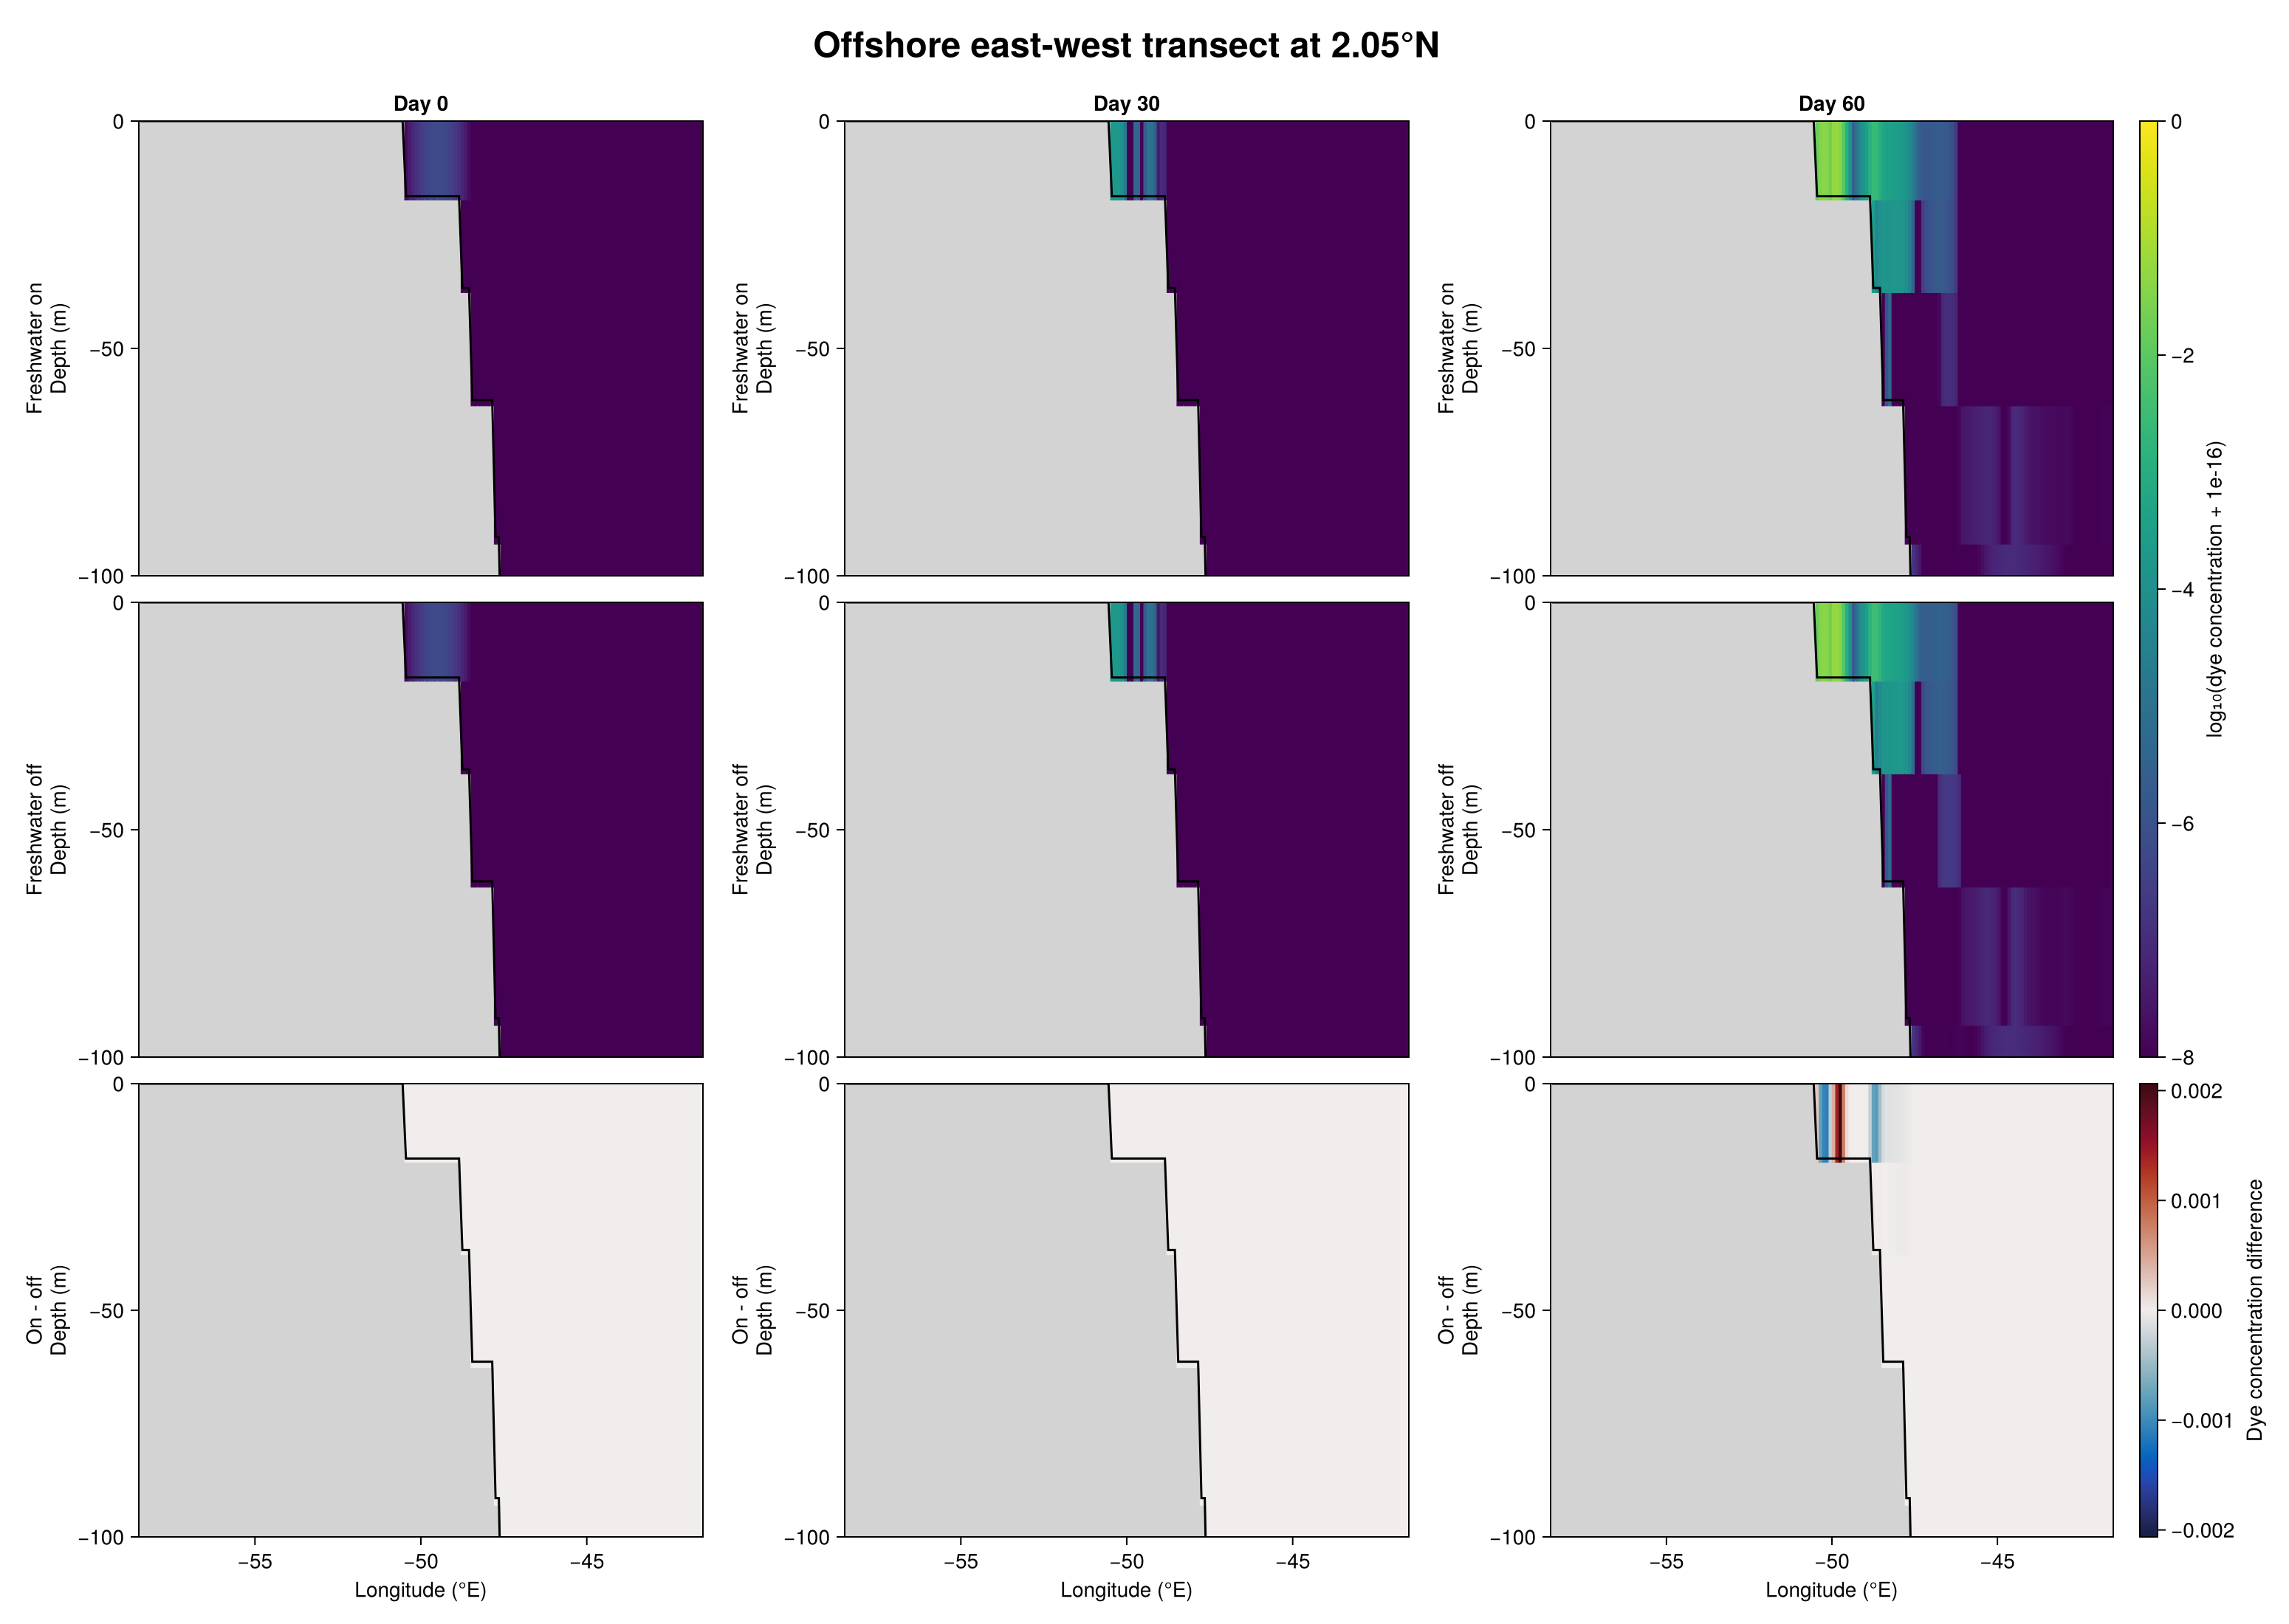

Downstream east-west transect
  requested coordinate: 3.0
  selected coordinate: 3.05°N
  freshwater-on days: [0.0, 30.0, 60.0]
  freshwater-off days: [0.0, 30.0, 60.0]
  difference range: ±1.4858537724649068e-6
  saved as: amazon_dye_transect_3N_days_0_30_60.png


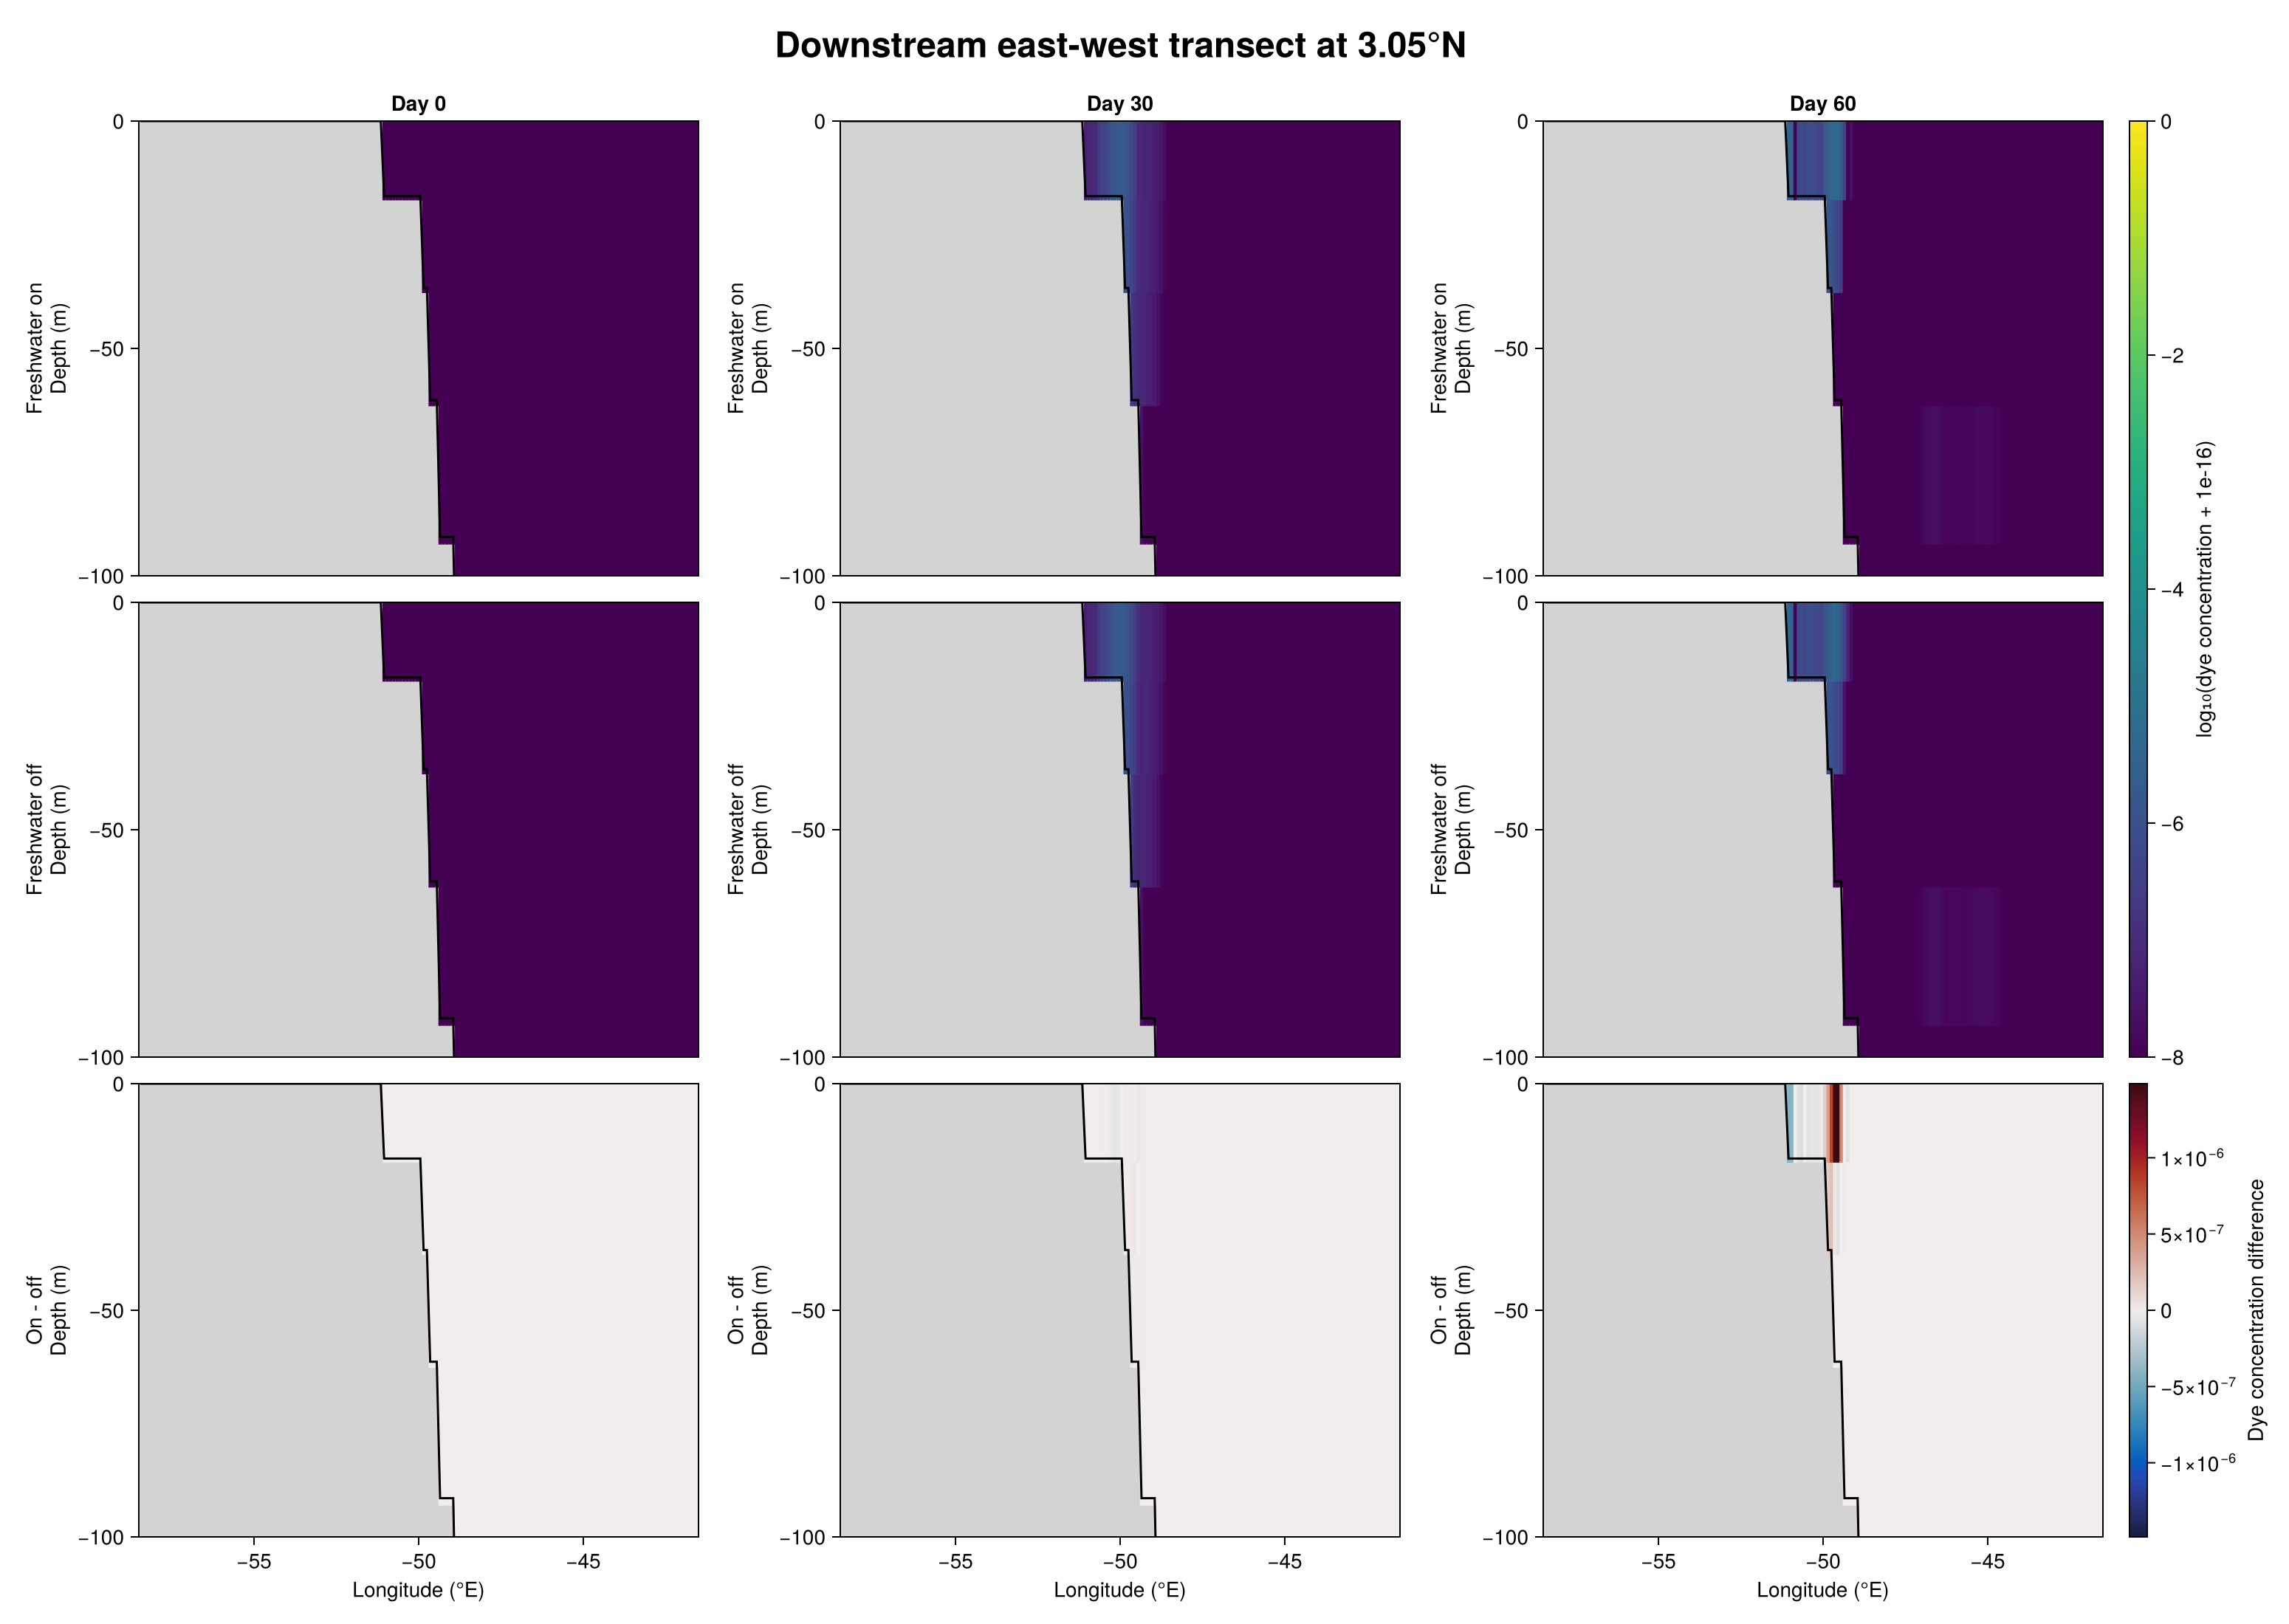

Near-mouth north-south transect
  requested coordinate: -49.5
  selected coordinate: -49.55°E
  freshwater-on days: [0.0, 30.0, 60.0]
  freshwater-off days: [0.0, 30.0, 60.0]
  difference range: ±0.0034598708152770996
  saved as: amazon_dye_transect_49_5W_days_0_30_60.png


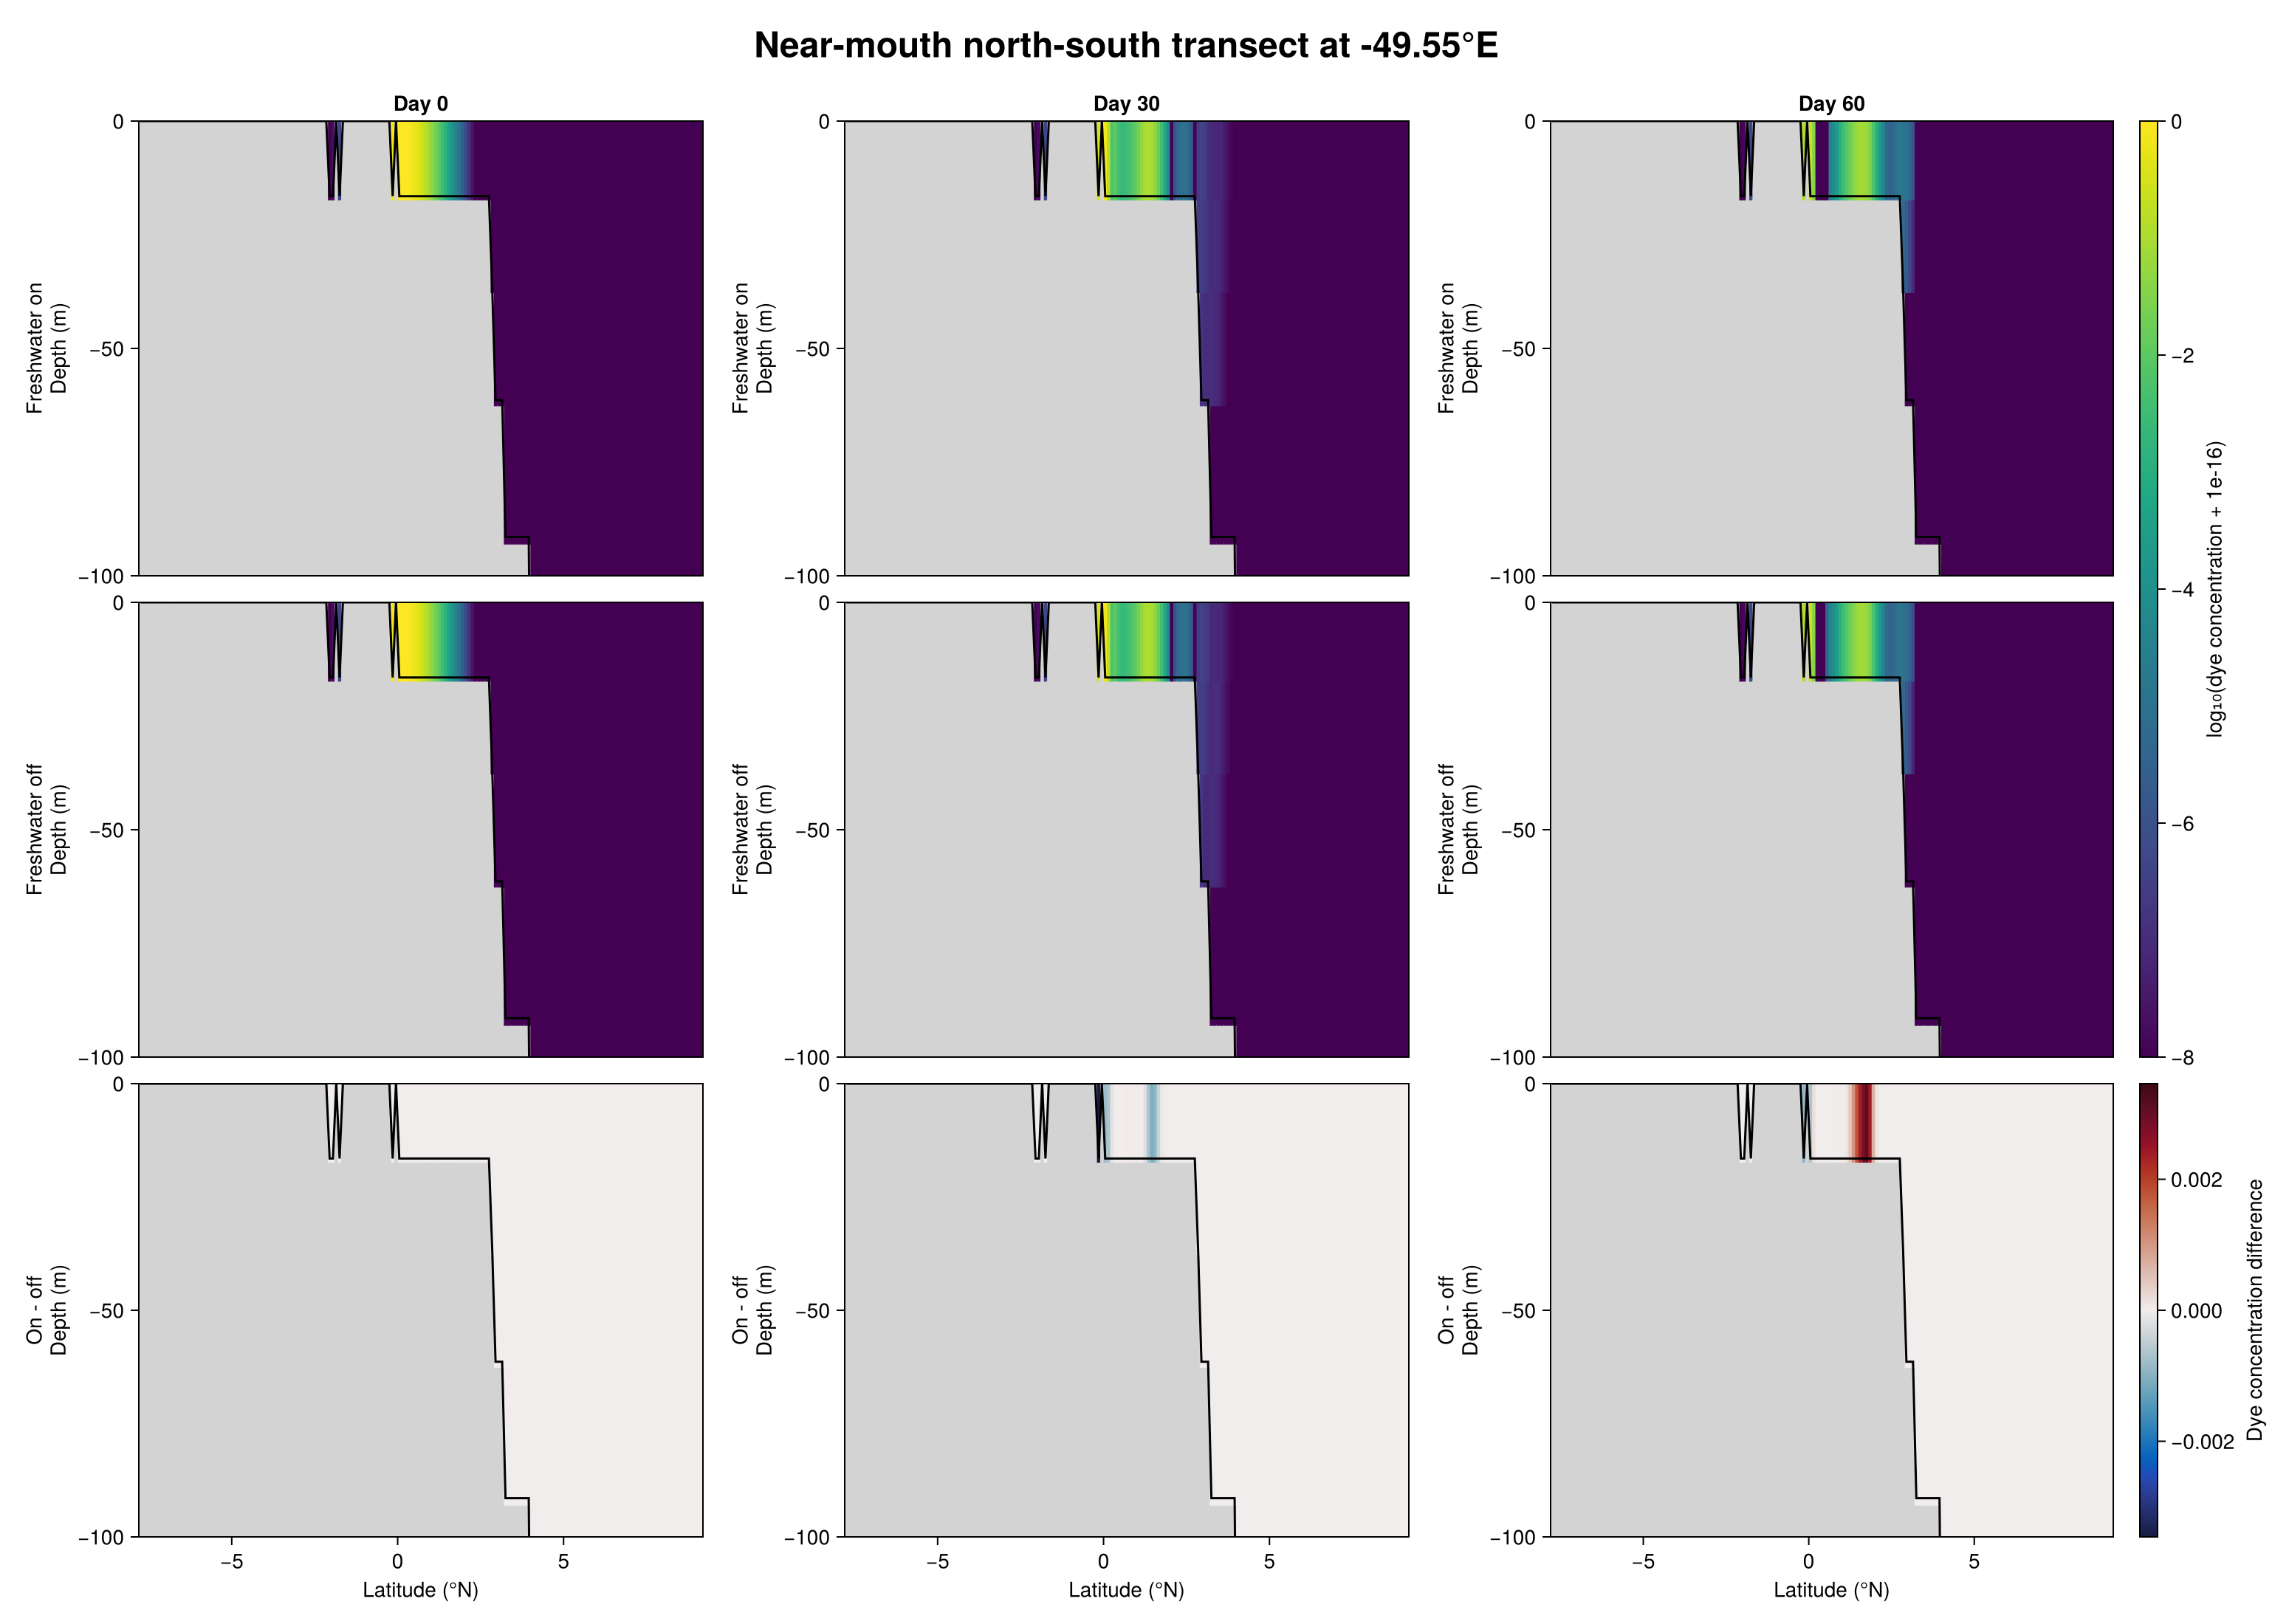

CairoMakie.Screen{IMAGE}


In [19]:
# create + display the offshore east-west transect at approximately 2°N
east_west_2N_figure = plot_transect_over_time(
    dye_on, dye_off, bottom_height, λ, φ, z, target_days;
    orientation = :east_west,
    fixed_coordinate = 2.0,
    transect_name = "Offshore east-west transect",
    filename = "amazon_dye_transect_2N_days_0_30_60.png"
)
display(east_west_2N_figure)

# create + display the downstream east-west transect at approximately 3°N
east_west_3N_figure = plot_transect_over_time(
    dye_on, dye_off, bottom_height, λ, φ, z, target_days;
    orientation = :east_west,
    fixed_coordinate = 3.0,
    transect_name = "Downstream east-west transect",
    filename = "amazon_dye_transect_3N_days_0_30_60.png"
)
display(east_west_3N_figure)

# create + display the near-mouth north-south transect at approximately -49.5°E
north_south_figure = plot_transect_over_time(
    dye_on, dye_off, bottom_height, λ, φ, z, target_days;
    orientation = :north_south,
    fixed_coordinate = -49.5,
    transect_name = "Near-mouth north-south transect",
    filename = "amazon_dye_transect_49_5W_days_0_30_60.png"
)
display(north_south_figure)